In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/cleaned_sales_data.csv")

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,quantity,discount,profit,order_year,order_month,order_month_name,order_quaterly,profit_margin,shipping_days,sales_category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,4,16.00,3,Medium
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,4,30.00,3,High
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2,47.00,4,Low
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,4,-40.00,7,High
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,4,11.25,7,Low


In [4]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Average Order Value: 458.61


In [5]:
df['order_id'].count()

np.int64(9994)

In [6]:
df["order_id"].nunique()

5009

In [7]:
df['order_id'].value_counts()

order_id
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
                  ..
CA-2015-149734     1
US-2017-119662     1
US-2014-157231     1
CA-2015-105508     1
CA-2014-111360     1
Name: count, Length: 5009, dtype: int64

In [8]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'order_year',
       'order_month', 'order_month_name', 'order_quaterly', 'profit_margin',
       'shipping_days', 'sales_category'],
      dtype='object')

In [12]:
# Sales by Category
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
category_sales

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

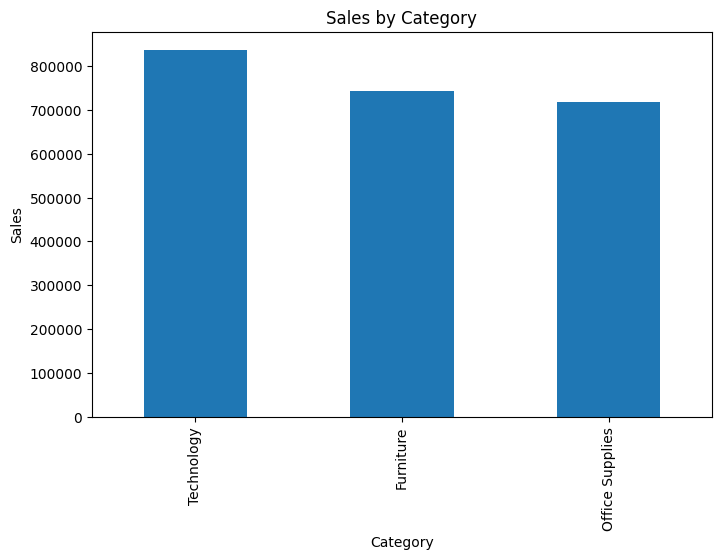

In [15]:
category_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [19]:
# Profit by Category
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
category_profit

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

Text(0.5, 1.0, 'profit by category')

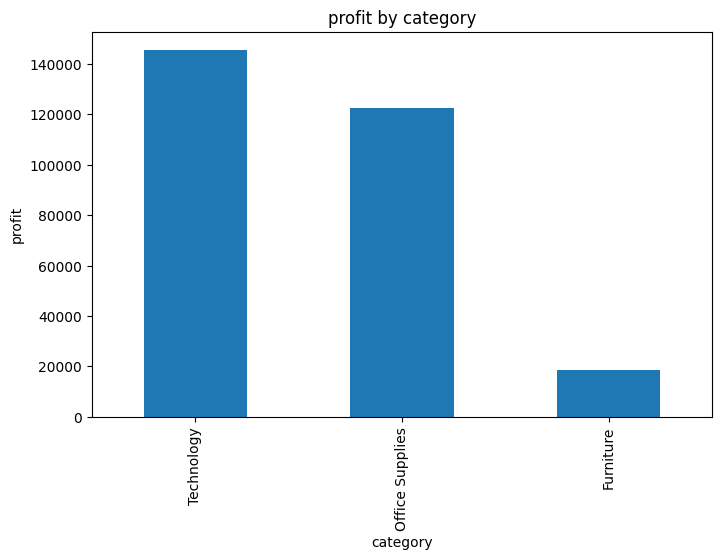

In [21]:
category_profit.plot(kind='bar' , figsize=(8,5))
plt.xlabel('category')
plt.ylabel('profit')
plt.title('profit by category')

In [24]:
# sales by region
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)
region_sales

region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64

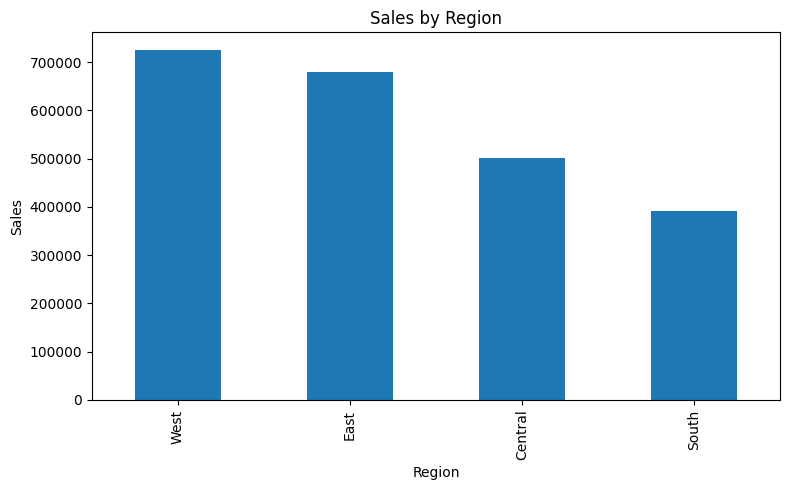

In [25]:
region_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [26]:
# profit by region
region_profit = df.groupby("region")["profit"].sum().sort_values(ascending=False)
region_profit

region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64

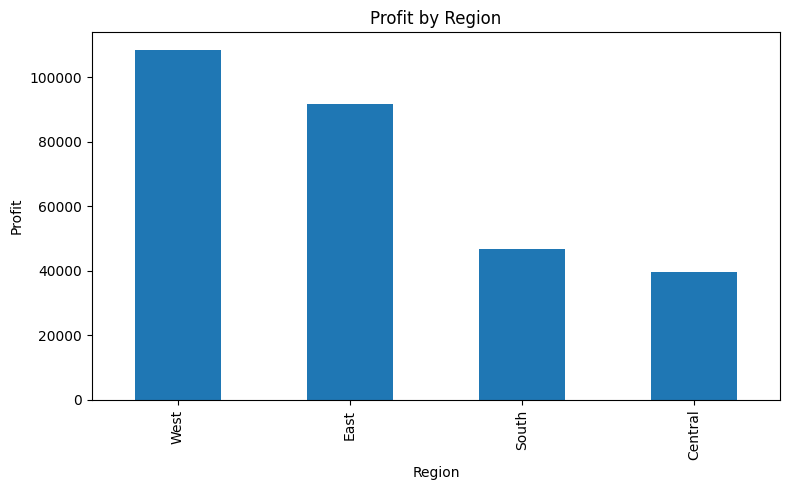

In [27]:
region_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [33]:
# monthly sales trend
monthly_sales = df.groupby(["order_year", "order_month"])["sales"].sum().reset_index()
monthly_sales["year_month"] = monthly_sales["order_year"].astype(str) + "-" + monthly_sales["order_month"].astype(str)

monthly_sales.head()

,order_year,order_month,sales,year_month
0,2014,1,14236.895,2014-1
1,2014,2,4519.892,2014-2
2,2014,3,55691.009,2014-3
3,2014,4,28295.345,2014-4
4,2014,5,23648.287,2014-5


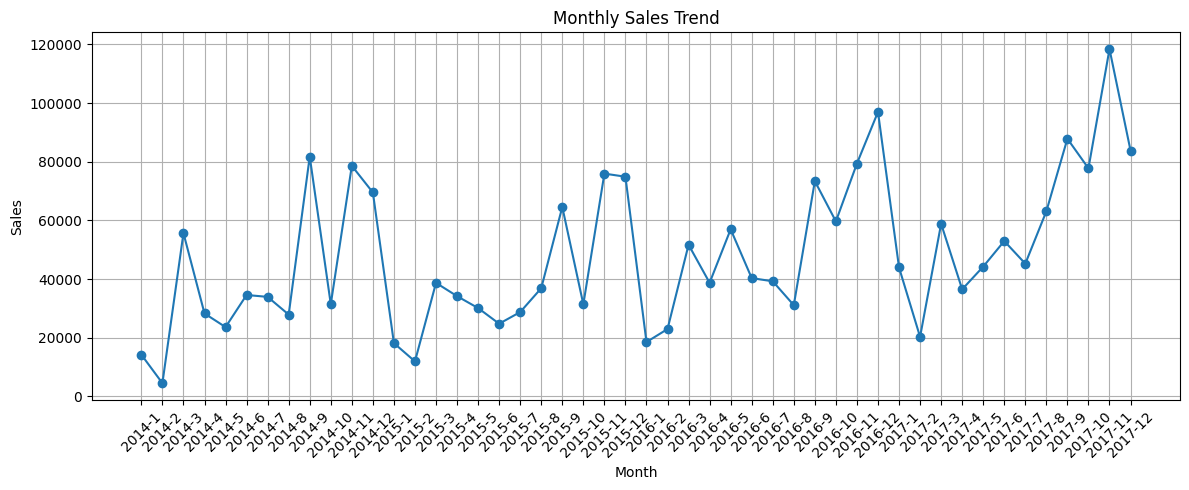

In [34]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["year_month"], monthly_sales["sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [39]:
# monthly profit trend

monthly_profit = df.groupby(['order_year','order_month'])['profit'].sum().reset_index()
monthly_profit['year_month'] = monthly_profit['order_year'].astype(str)+'-'+monthly_profit['order_month'].astype(str)
monthly_profit.head()

,order_year,order_month,profit,year_month
0,2014,1,2450.1907,2014-1
1,2014,2,862.3084,2014-2
2,2014,3,498.7299,2014-3
3,2014,4,3488.8352,2014-4
4,2014,5,2738.7096,2014-5


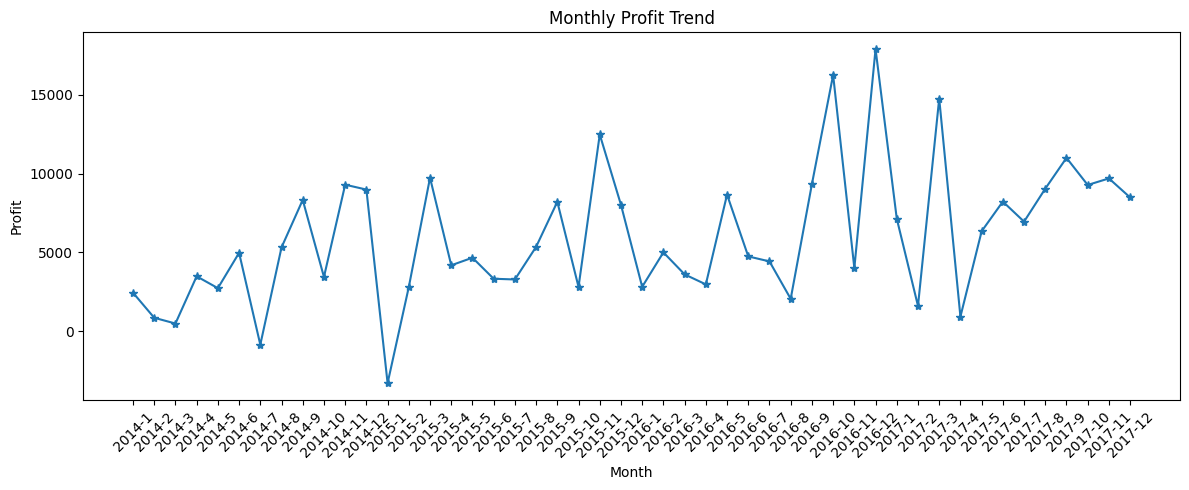

In [41]:
monthly_profit = df.groupby(["order_year", "order_month"])["profit"].sum().reset_index()
monthly_profit["year_month"] = monthly_profit["order_year"].astype(str) + "-" + monthly_profit["order_month"].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_profit["year_month"], monthly_profit["profit"], marker="*")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
# top 10 products sales

top_10_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
top_10_products

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64

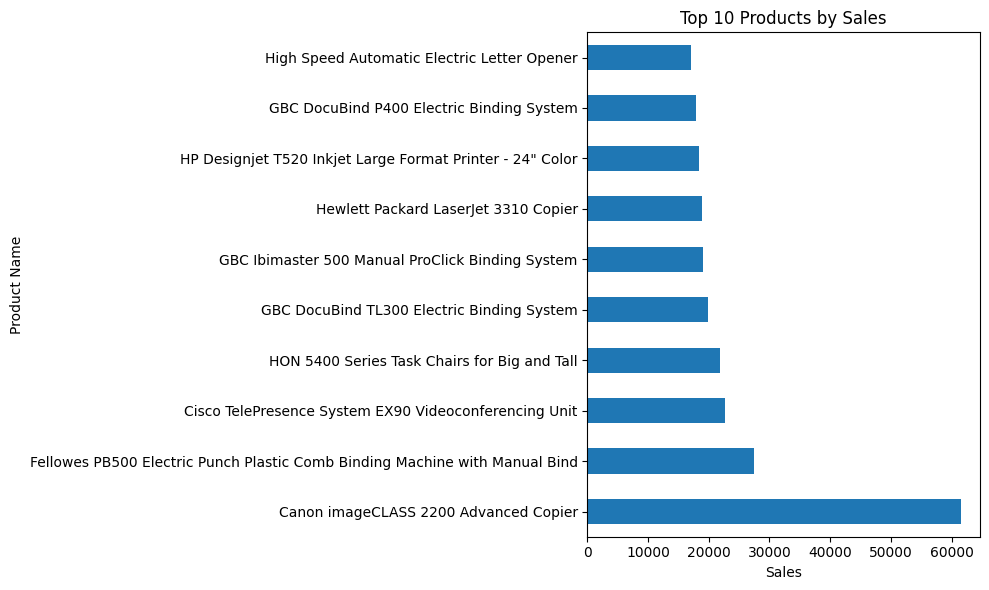

In [44]:
top_10_products.plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

In [45]:
# Top 10 Customers by Sales
top_customers = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
top_customers

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

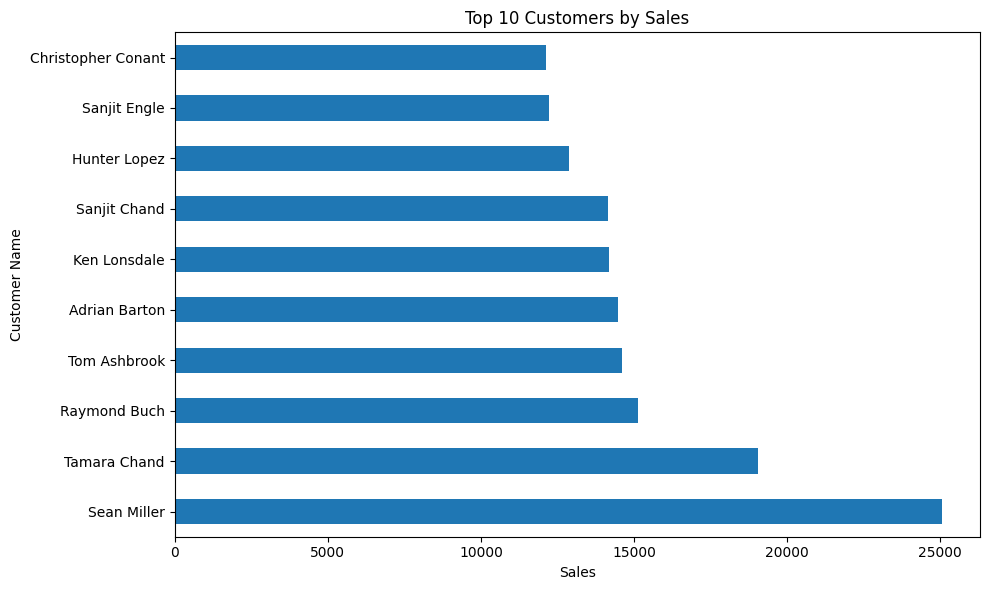

In [46]:
top_customers.plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.show()

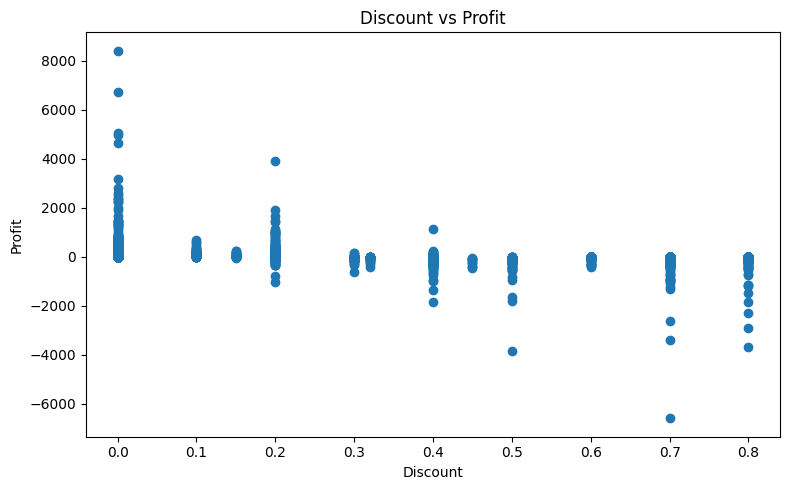

In [47]:
# discount vs profit 
plt.figure(figsize=(8,5))
plt.scatter(df["discount"], df["profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [48]:
# Segment-wise Sales
segment_sales = df.groupby("segment")["sales"].sum().sort_values(ascending=False)
segment_sales

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

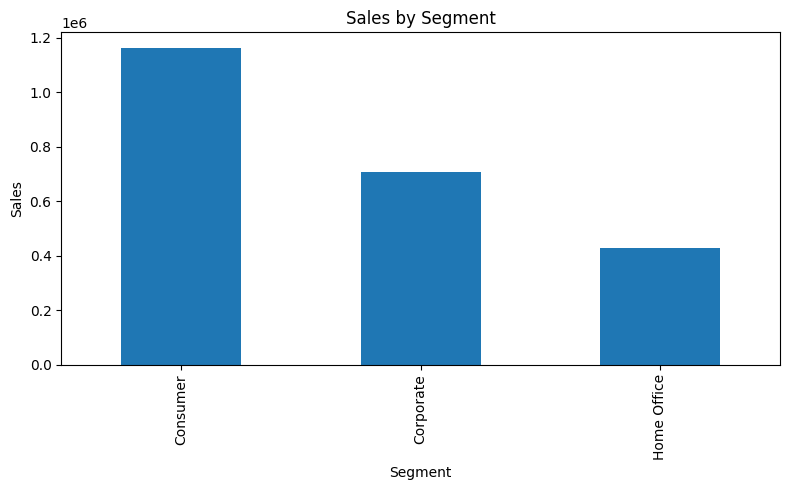

In [49]:
segment_sales.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

In [50]:
# State-wise Sales
state_sales = df.groupby("state")["sales"].sum().sort_values(ascending=False).head(10)
state_sales

state
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: sales, dtype: float64

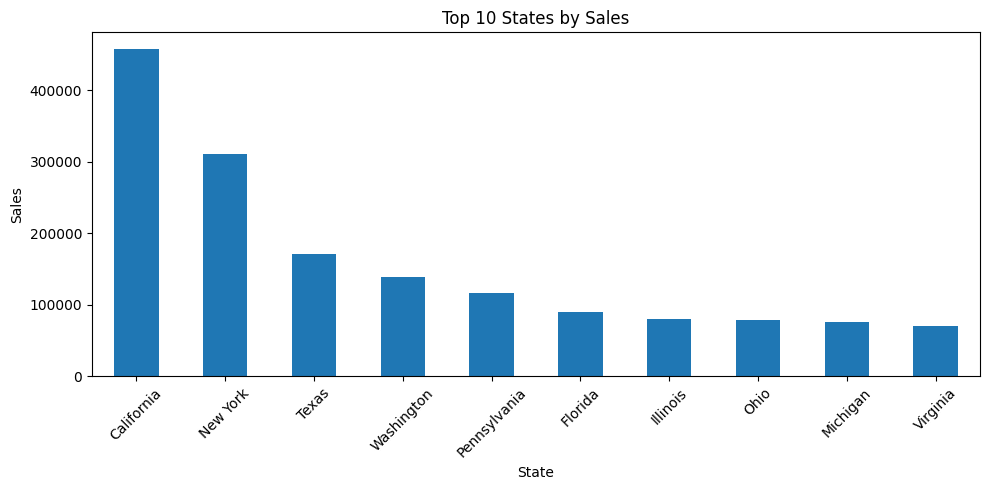

In [51]:
state_sales.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()